<p style="font-size: 40px; font-weight: bold;">
Partie I : Mesure de la fluorescence de l'huile d'olive extra vierge par un spectromètre et une LED blanche
</p>
Cette première partie est dédiée à l'exploitation des données obtenues lors de la mesure de la fluorescence de l'huile d'olive extra vierge. Nous allons voir que le traitement des données nous permet d'identifier la composition de l'huile d'olive extra vierge à partir des spectres d'absorption et d'émission de fluorescence.

<p style="font-size: 30px;">1. Spectre de la source et spectre d'absorption de l'huile d'olive</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger le fichier
# sep='\s+' : sépare par espaces ou tabulations
# decimal=',' : indique que les nombres utilisent la virgule comme séparateur décimal
# comment='>' : ignore les lignes qui commencent par '>' (comme >>>>>End)
df_tr = pd.read_csv("data/CORDEES8_HUILE.txt", 
                 sep='\s+', 
                 header=None, 
                 decimal=',', 
                 comment='>')

# Plot
plt.figure(2)
plt.plot(df_tr[0], df_tr[1], linestyle='-')
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Intensité transmise (u.a.)")
plt.title("Spectre de transmission")
plt.grid(True)
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_73888/246488379.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_73888/246488379.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


ModuleNotFoundError: No module named 'pandas'

In [2]:
# Charger le fichier
# sep='\s+' : sépare par espaces ou tabulations
# decimal=',' : indique que les nombres utilisent la virgule comme séparateur décimal
# comment='>' : ignore les lignes qui commencent par '>' (comme >>>>>End)
df_led = pd.read_csv("data/CORDEES.txt", 
                 sep='\s+', 
                 header=None, 
                 decimal=',', 
                 comment='>')

# Plot
plt.figure(2)
plt.plot(df_led[0], df_led[1], linestyle='-')
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Intensité (u.a.)")
plt.title("Spectre de la LED blanche")
plt.grid(True)
plt.show()

plt.figure(3)
plt.plot(df_led[0], df_led[1]-200,  linestyle='-', label="LED")
plt.plot(df_tr[0], 0.75*((df_tr[1])-200),  linestyle='-', label="Transmission")
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Intensité (u.a.)")
plt.title("Spectre de la LED blanche et le spectre de transmission")
plt.grid(True)
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_72762/3542244580.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_72762/3542244580.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


NameError: name 'pd' is not defined

Le u.a. signifie unité arbitraire car la valeur ne représente pas une grandeur physique mais simplement un niveau d'intensité. <br>
Maintenant, nous allons essayer d'obtenir le spectre d'absorbance à partir de ces deux spectres. En effet, seul le spectre de transmittance ne permet pas de quantifier l'absorption car il faut connaître la distribution spectrale de la source illuminant l'huile d'olive. Pour cela, nous allons nous servir de la formule suivante : $$ A = -\log_{10}\bigg (\frac{I_T(\lambda)}{I_0(\lambda)}\bigg) $$
où $I_T(\lambda)$ est l'intensité transmise et $I_0(\lambda)$ est l'intensité de la LED. L'indice 10 désigne la base du logarithme. Si $A=0$, cela siginifie que la transmission est totale et si $A=2$ la transmission est de 1%.


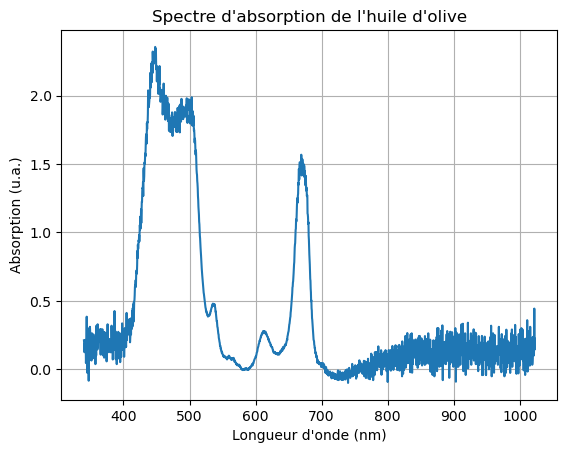

In [113]:
A=-np.log10((0.75*(df_tr[1]-190))/(df_led[1]-190))

plt.figure(4)
plt.plot(df_led[0], A,  linestyle='-')
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Absorption (u.a.)")
plt.title("Spectre d'absorption de l'huile d'olive")
plt.grid(True)
plt.show()

Sur ce spectre, nous voyons deux contributions principales. Une dans le bleu (450 nm) et une autre dans le rouge (670 nm). Si vous vous souvenez, nous avions remarqué que la lumière bleue ne traversait pas l'huile d'olive (voir les <a href="#images_huile_bleu" >images</a> en dessous). Et bien nous en avons l'explication, l'absorption du bleu est très forte. Puisque l'absorption est linéaire en fonction de la longueur de la cuve (notre verre), plus le verre est grand, moins la lumière en sortie est intense. La loi reliant l'absorption à la longueur du verre est : $$ A=\varepsilon C L$$ où $\epsilon$ est le coefficient d'extinction molaire et $C$ la concentration. <br>
Toutes ces infos ne sont pas forcément nécessaire pour le poster où la présentation, mais ce sont de bonnes choses à savoir pour vous et pour répondre aux questions.

In [126]:
# Source - https://stackoverflow.com/a/38546126
# Posted by Salvador Dali
# Retrieved 2026-03-15, License - CC BY-SA 3.0

#Afficher une image depuis une cellule code

from IPython.display import HTML, display

display(HTML("""
<table>
<tr>
    <td><img id="images_huile_bleu" src='images/huile_bleu_side.jpg' width="500"></td>
    <td><img src='images/huile_bleu_top.jpg' width="300"></td>
</tr>
</table>
"""))


,


Sur ces deux images, on voit bien que la lumière bleue perd très rapidement en intensité dans l'huile d'olive, elle est donc absorbée. On voit apparaître une couleur orangée en fluorescence. Je trouve que cela était encore plus parlant avec le laser bleu, donc peut-être que la photo avec le laser est plus intéressante. En revanche, nous observons sur le spectre que le vert (532 nm pour le laser) est très peu absorbé. C'est ce qui explique que le faisceau lumineux du laser vert soit transmis. Mais il y a quand même un phénomène d'absorption car nous avons observé de la fluorescence rouge. <br>

<p style="font-size: 30px;">2. Spectre d'émission de la fluorescence</p>

Dans cette deuxième partie, nous allons nous intéresser à la lumière fluorescente émise par l'huile d'olive extra vierge. Pour mesurer son spectre, nous avons utilisé le spectromètre dans une géométrie différente (**je n'ai pas pris de photo, il faudra faire un schéma pour votre diapo je pense**). Nous l'avons placé à 90° du verre plutôt que derrière celui-ci. De cette manière nous n'avons pas détecté la lumière transmise par l'huile mais seulement celle de fluorescence.

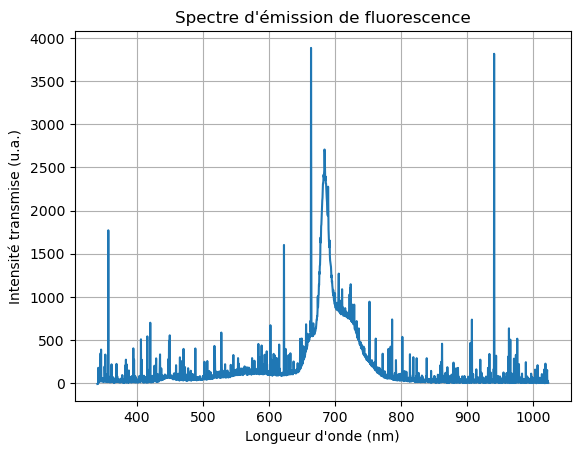

In [115]:
# Charger le fichier
# sep='\s+' : sépare par espaces ou tabulations
# decimal=',' : indique que les nombres utilisent la virgule comme séparateur décimal
# comment='>' : ignore les lignes qui commencent par '>' (comme >>>>>End)
df_em = pd.read_csv("data/CORDEES_HUILE_SPECTRE_EM_2s.txt", 
                 sep='\s+', 
                 header=None, 
                 decimal=',', 
                 comment='>')

# Plot
plt.figure(2)
plt.plot(df_em[0], df_em[1]-210, linestyle='-')
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Intensité transmise (u.a.)")
plt.title("Spectre d'émission de fluorescence")
plt.grid(True)
plt.show()

En observant ce spectre, nous voyons deux principaux pics de fluorescence, un premier vers 680 nm et un second vers 720 nm. Ces deux pics correspondent bien à la couleur rouge observée lorsque nous avons illuminé l'huile avec la LED ou le laser vert. Je mets une image juste en dessous pour illustrer cela.

In [121]:
from IPython.display import display, HTML

display(HTML("""
<table>
<tr>
    <td><img id="images_huile_bleu" src='images/huile_fluo_laser.jpg' width="400"></td>
    <td><img src='images/huile_fluo_led.jpg' width="400"></td>
</tr>
</table>
"""))

,


L'image de gauche montre la fluorescence de l'huile d'olive illuminée par un laser vert 532 nm et l'image de droite la fluorescence de cette même huile illuminée par la LED blanche devant laquelle j'ai inséré un filtre vert. Sur les deux figures on observe une très bonne transmission de la lumière verte, comme attendu et avec une fluorescence rouge. <br>

Maintenant que nous avons nos spectres d'absorption et d'émission nous pouvons les comparer en les insérant sur une même figure. Il faut faire attention lors de la lecture car les deux spectres ont des axes $y$ différents. On peut en placer un à gauche et un autre à droite par exemple.

Text(0.5, 0.98, "Spectres d'absorption et d'émission de l'huile d'olive extra vierge bio de chez Carrefour")

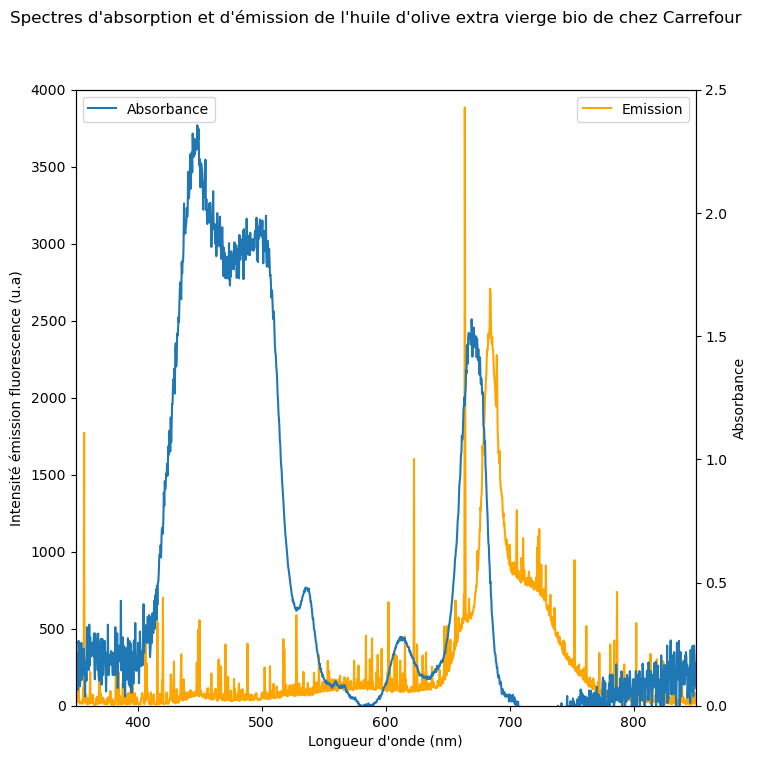

In [127]:
# Plot
fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

ax1.plot(df_em[0], df_em[1]-210, color="orange", label="Emission")
ax1.set_xlim(350, 850)
ax1.set_ylim(-0.3, 4000)
ax1.set_xlabel("Longueur d'onde (nm)")
ax1.set_ylabel("Intensité émission fluorescence (u.a)")
ax1.legend(loc='upper right')

ax2.plot(df_tr[0], A, label="Absorbance");
ax2.set_ylim(0, 2.5)
ax2.set_xlim(350, 850)
ax2.set_ylabel("Absorbance")
ax2.legend(loc='upper left')

fig.suptitle("Spectres d'absorption et d'émission de l'huile d'olive extra vierge bio de chez Carrefour")

Voilà la figure qui présente les spectres d'absorption et d'émission. On remarque bien le décalage en longueur d'onde entre l'absorption qui a lieu dans le bleu, vert et rouge et l'émission qui a lieu dans le rouge plus proche de l'infrarouge. Nos résultats ne contredisent pas la théorie qui dit que la fluorescence se fait par une réduction de l'énergie du photon et donc l'augmentation de la valeur de sa longueur d'onde. $$ E=\frac{hc}{\lambda}$$

Si $E$ diminue alors $\lambda$ (longueur d'onde) augmente. <br>

<p style="font-size: 30px;">3. Interprétation des résultats</p>

Maintenant que nous avons traité les données pour un peu les faire parler, nous allons passer à l'interprétation de nos résultats. Nous allons les comparer avec des résultats référencés pour vérifier s'ils sont corrects ou non. En physique et en science expérimentale, un résultat faux n'est pas toujours bon à jeter à la poubelle, il permet de comprendre ses erreurs et d'améliorer son approche expérimentale. <br>
Tout d'abord, vérifions ce que disent les études sur la fluorescence de l'huile d'olive ! <br>

En parcourant internet, j'ai trouvé quelques publications intéressantes qui étudient la fluorescence de l'huile d'olive - je les ai téléversées <a color="blue" href="https://github.com/ltoguh/fluorescence_project_cordees_2026/tree/master/refs">ici</a>. Un résultat intéressant semble être le fait que seule l'huile d'olive extra vierge présente cette absorption dans le vert et donc cette fluorescence rouge observée. Cela constitue un résultat très intéressant car cela veut dire qu'il suffit d'illuminer de l'huile d'olive pour savoir si celle-ci est extra vierge. On peut alors déceler les éventuelles fraudes.

<p style="text-align:center"><img src="images/domi_abs_lu_caro_pheo.png" align="center" ></p>

En comparant ce spectre d'absorbance tiré de la réf <a href="#domi">[1]</a> avec le spectre d'absorbance mesuré, on remarque la forme similaire entre notre spectre et celui de la carotéine entre 400 nm et 550nm. En revanche, on remarque une différence fondamentale, la carotéine n'absorbe pas le rouge. Cela veut dire que notre pic mesuré est dû à l'absorption de quelque chose d'autre. <br>
Regardons d'autres spectres, <p style="text-align:center"><img src="images/deltares_abs.png" align="center" ></p>
Sur ce spectre tiré de la réf <a href="#deltares">[2]</a>, on retrouve notre carotène mais aussi le pic dans le rouge qui semble être associé à la chlorophylle. Il existe d'ailleurs deux types de chlorophylle qui ont des signatures spectrales bien différentes, intéressant... <br>

Pour ce qui est de l'émission de fluorescence que nous avons mesurée, nous comparons encore une fois avec les résultats obtenus avec des techniques plus "sérieuses". Par exemple, le spectre d'émission de la chlorophylle trouvé dans <a href="#santab">[3]</a>  <p style="text-align:center"><img src="images/em_santab.png" align="center" ></p>
On remarque une nouvelles fois la similitude entre notre résultat et celui trouvé dans la littérature scientifique.

<p style="font-size: 30px;">4. Conclusion sur la partie expérimentale</p>
Nous avons obtenu les spectres de fluorescence de l'huile d'olive avec un dipositif très simple composé d'une LED blanche et d'un spectromètre. Une étude comparative de nos résultats avec ceux de la littérature scientifique nous a permis d'identifier notre huile comme étant extra vierge. <br>
Les mesures faites à l'aide du spectromètre ont montré les limites de la technique car la très faible intensité de la fluorescence rend sa détection un peu plus délicate dans un dispositif aussi simple. Pour une mesure plus robuste, il faudrait se tourner vers des équipements dédiés à ce type de mesures. <br>
Il aurait fallu faire une mesure à vide sur le verre vide pour s'assurer que celui-ci n'influence pas sur les spectres mesurés. J'ai vérifié sans sauvegarder après votre départ et je n'ai pas constaté de différence avec et sans verre entre la LED et le spectromètre. 
<br>

Je suis plutôt satisfait du résultat, je n'avais jamais essayé de mesurer ces signaux de fluorescence et je craignais de ne pas réussir à observer l'émission de fluorescence. Mais au final, avec un peu de persévérance, on y arrive toujours.

# Références

<a id="domi">[1]</a> <a href="refs/deltares.pdf">"In vivo chlorophyll fluorescence measurements", 2012<br>
<a id="deltares">[2]</a> <a href="refs/domi.pdf"> V. Domenici et al., "Extraction of Pigment Information from Near-UV Vis Absorption
Spectra of Extra Virgin Olive Oils", Journal of Agricultural and Food Chemistry, 2014</a> <br>
<a id="santab">[3]</a> S. Santabarbara et al., "Influence of the Wavelength of Excitation and Fluorescence Emission Detection on the Estimation of Fluorescence-Based Physiological Parameters in Different Classes of Photosynthetic Organisms", InTechOpen, 2020</a>



<p style="font-size: 40px; font-weight: bold;">
Partie II : Microscopie de fluorescence et images et de cellules biologiques
</p>

Dans cette deuxième partie, nous allons discuter des images de cellules biologiques que nous avons prises avec Guillaume Gilbert le biologiste qui nous a présenté son microscope de fluorescence. Les cellules que nous avons observées sont des cellules musculaires de rat dénomées H9c2. C'est Guillaume qui s'était chargé de la préparation et du marquage en fluorescence. Je vous rappelle que l'ADN contenue dans le noyau des cellules a été marqué avec Hoechst-33342 (voir le <a color="blue" href="https://www.thermofisher.com/fr/fr/home/references/protocols/cell-and-tissue-analysis/protocols/hoechst-33342-imaging-protocol.html">lien</a> pour avoir plus d'info sur la procédure de marquage !) et le cytosquelette a été marqué avec AlexaFluo488. Pour aller plus loin sur le marquage, je vous laisse jeter un coup d'oeil à l'immunofluorescence. <br>

Comme vous le savez maintenant, chaque marqueur doit être illuminé à la bonne longueur d'onde d'excitation $\lambda_{ex}$ pour pouvoir fluorescer. Pour Hoechst-33342, l'illumination est dans l'UV ($\lambda_{ex}=350$ nm) tandis que pour AlexaFluor elle se fait dans le vert ($\lambda_{ex} = 488$ nm). De cette manière, en illuminant les cellules avec ces deux $\lambda_{ex}$, on peut consécutivement récupérer la lumière fluorescée par les noyaux et le cytosquelette. <br>

Autre info importante donc nous n'avons pas forcément discuté, les couleurs sur les images de fluorescence ne correspondent pas forcément aux longueurs d'ondes d'émission des marqueurs. La caméra est une caméra noir et blanc (elle ne voit pas les couleurs), c'est alors un choix d'affichage sur l'écran. Bien sûr, certaines conventions existent, ainsi on retrouve souvent le noyau en bleu et le cytosquelette en vert. <br>

Les images des cellules sont présentées ci-dessous,
<table>
  <tr>
    <td><img src="images/image_BF_crop.png" alt="Image 1" width=500px;></td>
    <td><img src="images/fluo_crop.png" alt="Image 2"></td>
  </tr>
</table>

L'image de gauche est l'image obtenue avec un microscope classique, c'est-à-dire que l'on observe simplement la lumière transmise par l'échantillon. On observe un flagrant manque de contraste, comme si la lame était dépourvue d'échantillon. En effet, les cellules absorbent très peu la lumière (au moins visible) et ne sont pas visibles avec un microscope classique. C'est pour cela que la microscopie de fluorescente est notamment intéressante, elle permet d'imager des échantillons qui absorbent très peu la lumière. Mais pour cela il faut marquer les structures d'intérêt. <br>
Ainsi, sur l'image de fluorescence à droite, on observer les cellules avec en bleu le noyau et en vert le cytosquellete. Je rappelle que sur cette image, deux images ont été fusionnées : celle des noyaux seuls et celle du cytosquelette seul. Si vous voulez les images séparées, je pourrai aussi les déposer ici. <br>
Dans le cytosquelette, on voit bien les filaments d'actine